In [17]:
# 1. Data Preparation

# We scale all features before applying K-Means clustering.
# Scaling is essential because K-Means is
# distance-based, and features with larger values can dominate the clustering process.

In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('q2_customers.csv')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [19]:
# 2. Elbow Method

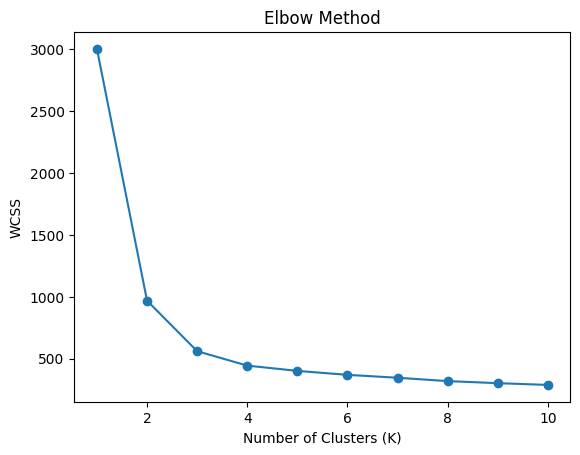

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [21]:
# The elbow point appears at K = 4
# This is where the reduction in WCSS slows down, indicating an optimal number of
# Clusters

In [22]:
# 3. K-Means Clustering

In [23]:
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.037500,89814.075000,2.462500,5296.362500,148.000000,7.487500
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.517647,89036.164706,2.588235,5750.952941,65.223529,7.541176


In [24]:
# Cluster Interpretation

# - Cluster 0: High spenders with frequent visits
# - Cluster 1: Low spenders with infrequent visits
# - Cluster 2: Moderate customers
# - Cluster 3: High basket size but low frequency

# These clusters help businesses target different customer segments.

In [25]:
# 4. PCA

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


In [27]:
# PC1 captures overall customer activity (spend + visits).

# PC2 captures recency and diversity of purchases.

# These components simplify high-dimensional data into interpretable axes.

In [28]:
# 5. Visualization

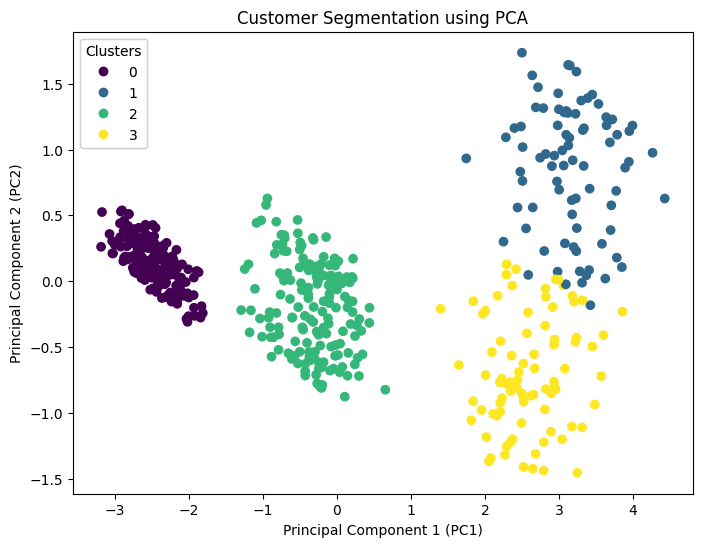

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot with clusters
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
)

# Title and labels
plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

# Legend (IMPORTANT for marks)
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.show()

In [30]:
# The scatter plot visualizes customer segments in a reduced 2D space using PCA.
# Each color represents a different cluster, and clear separation between clusters
# indicates that K-Means has effectively grouped customers with similar behavior.
# Clusters that are well-separated suggest distinct customer segments, which can be targeted with different business strategies.